# Optimizing APLC Masks with the Augmented Lagrangian

In the [APLC Optimization](APLC_Optimization.ipynb) how-to we dug a dark hole by *summing* a contrast cost and a throughput cost with a hand-tuned weight (the Lagrange multiplier `8e-5`). That **static penalty** has two drawbacks:

1. You have to grid-search the weight to balance contrast against throughput — the notebook itself flags this as "worth its own tutorial."
2. The contrast is never a *target* you ask for directly; it only emerges from whatever the weight happens to produce.

`dygdug`'s `AugmentedLagrangian` poses the *same* design as a **constrained** problem instead:

> maximize throughput &nbsp;&nbsp; subject to &nbsp;&nbsp; (dark-hole contrast ≤ target), &nbsp;&nbsp; 0 ≤ apodizer ≤ 1

It treats the contrast as a **hard constraint** you state directly (e.g. `1e-10`), and updates the Lagrange multipliers **automatically** between solves — so there is no weight to grid-search. It follows the augmented-Lagrangian structure of Por, *Proc. SPIE* **12180**, 121805J (2022).

Two more features make it the right tool for *manufacturable* APLCs:

- **A linear (field) contrast constraint** (`constraint_kind="field"`) bounds the real and imaginary parts of the dark-hole field. Its feasible set is a polytope whose **vertices are binary**, so maximizing throughput pushes the apodizer toward a binary {0, 1} solution.
- **Progressive relaxation** blurs the apodizer between solves to escape local minima (also Por 2022).

This how-to mirrors the setup of the APLC notebook, then swaps in the new optimizer.

## Instrument setup

We reuse the same segmented telescope, focal-plane mask, and Lyot stop as the [APLC Optimization](APLC_Optimization.ipynb) how-to so the results are directly comparable.

In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from prysm.propagation import prepare_executor
from prysm.segmented import VERTEX_TO_VERTEX_TO_FLAT_TO_FLAT
from prysm.mathops import set_backend_to_cupy, np

from dygdug.backend import asnumpy
from dygdug.masks import Pupil, FPM
from dygdug.coropt import VariablePupil
from dygdug.models import Coronagraph

# Define instrument parameters
circumscribed_diameter = 10.95e3
Npup = 512
Nfoc = 128
wvl = 1
fno = 13.66
efl = fno * circumscribed_diameter
lamD = wvl / circumscribed_diameter * efl
px_per_lamD = 4  # the "oversampling"
seg_diam = VERTEX_TO_VERTEX_TO_FLAT_TO_FLAT * 1800

# Variable (amplitude-apodized) entrance pupil
pupil = VariablePupil.hexagonal_segmented(
    Dpup=circumscribed_diameter,
    Npup=Npup,
    rings=3,
    segment_diameter=seg_diam,
    segment_separation=5,
    exclude=(0,),
    mode="amplitude",  # special argument for VariablePupil
)

In [2]:
# Use the GPU backend (optional: comment these two lines out to run on CPU).
set_backend_to_cupy()
pupil.data = np.asarray(pupil.data)

# prysm executor that controls the propagation
executor = prepare_executor(
    pupil_dx=circumscribed_diameter / Npup,
    pupil_samples=Npup,
    focal_dx=lamD / px_per_lamD,
    focal_samples=Nfoc,
    wavelength=wvl,
    efl=efl,
    focal_shift=(0, 0),
    kind="mdft",
)

# Annular focal-plane mask
fpm = FPM.annular(
    N=Nfoc,
    lamD=lamD,
    px_per_lamD=px_per_lamD,
    inner_radius=3,
    outer_radius=12,
)

# Annular Lyot stop
lyot = Pupil.annular(
    Dpup=circumscribed_diameter,
    Npup=Npup,
    inner_radius=0.2 * circumscribed_diameter / 2,
    outer_radius=0.8 * circumscribed_diameter / 2,
)

coro = Coronagraph(pupil=pupil, fpm=fpm, lyot_stop=lyot, executor=executor)

/home/jarenashcraft/anaconda3/envs/prysm_test/lib/python3.10/site-packages/cupyx/jit/_interface.py:247: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


## Dark hole and contrast target

The dark hole is the same 180°, 3–12 λ/D region as the APLC how-to. The difference is that with the augmented Lagrangian we *also* pick the **contrast we actually want** — here `1e-10` — and hand it to the optimizer as a constraint rather than encoding it in a penalty weight.

In [3]:
from dygdug.masks import annular_mask, ImgSamplingSpec, knife_edge_mask

# Image-plane sampling spec and dark hole
iss = ImgSamplingSpec(Nfoc, px_per_lamD, lamD=lamD)
dark_hole = annular_mask(iss, iwa=3, owa=12, theta_min=-90, theta_max=90)
dark_hole *= knife_edge_mask(iss, iwa=3)

# The contrast we will *require* in the dark hole (relative to the direct PSF peak).
target_contrast = 1e-10

# Reference (no-FPM) peak of the fully-open pupil, used only to normalize the
# coronagraphic intensity for display.  The apodizer is still all-ones here.
ref_field = coro.forward(wvl, include_fpm=False)
contrast_norm = float(np.max(np.abs(ref_field) ** 2))

## Building the AugmentedLagrangian

The optimizer needs the coronagraph, an inner optimizer **class** (not an instance), the dark hole, the wavelength(s), and the contrast target. The key choices:

- `optimizer=PrysmLBFGSB` — the *inner* solver. Each sub-problem is smooth, deterministic, and box-constrained with exact analytic gradients, so quasi-Newton **L-BFGS-B** is the right tool (far fewer iterations than first-order methods like Yogi/Adam).
- `constraint_kind="field"` — the linear constraint whose binary vertices yield a manufacturable apodizer.
- `normalize_throughput=True` — optimize *mean* transmission (O(1)) so the throughput objective stays on the same scale as the penalty term.
- `penalty` / `penalty_growth` — the augmented-Lagrangian penalty `rho` and how fast it ramps. **This pair drives both convergence and binarity; we return to it below.** The default `penalty_growth=10` multiplies `rho` *every outer step*, so set it deliberately.
- `lower_bounds` / `upper_bounds` — the `[0, 1]` box on the amplitude.

`contrast` is the true contrast target; the multipliers and penalty `rho` are updated for you across outer iterations. We start from a fully-open apodizer (all ones) and let the optimizer close it down only as much as the contrast constraint demands.

In [4]:
from prysm.x.optym import PrysmLBFGSB
from dygdug.coropt import AugmentedLagrangian

# Fully-open starting apodizer.
x0 = np.ones_like(pupil.data[pupil.mask], dtype="float64")

model = AugmentedLagrangian(
    coro=coro,
    optimizer=PrysmLBFGSB,
    dark_hole=dark_hole,
    wvl=[wvl],                 # monochromatic, as in the APLC notebook
    contrast=target_contrast,  # the hard dark-hole contrast target
    x0=x0,
    lower_bounds=np.zeros_like(x0),
    upper_bounds=np.ones_like(x0),
    constraint_kind="field",   # linear constraint -> binary-friendly
    normalize_throughput=True,
    throughput_weight=1.0,
    penalty=1.0,
    penalty_growth=2.0,        # ramp rho by 2x/step (the default 10x explodes)
    optimizer_kwargs={"maxls": 50},  # forwarded to PrysmLBFGSB
    ftol=1e-4,  # let inner solves exit early once the objective plateaus
    gtol=1e-6,
)

## The simplest run: `solve()`

`solve(outer_steps, inner_steps)` runs the whole outer loop for you: each outer iteration runs an inner L-BFGS-B solve, then updates the multipliers and grows the penalty. It returns the final apodizer vector and a per-iteration `history` (a list of info dicts).

This enforces the contrast constraint, but expect the result to be **gray, not binary** — the next section explains why and fixes it. Increase `outer_steps` / `inner_steps` for deeper contrast.

outer: 100%|██████████| 20/20 [00:18<00:00,  1.07it/s]


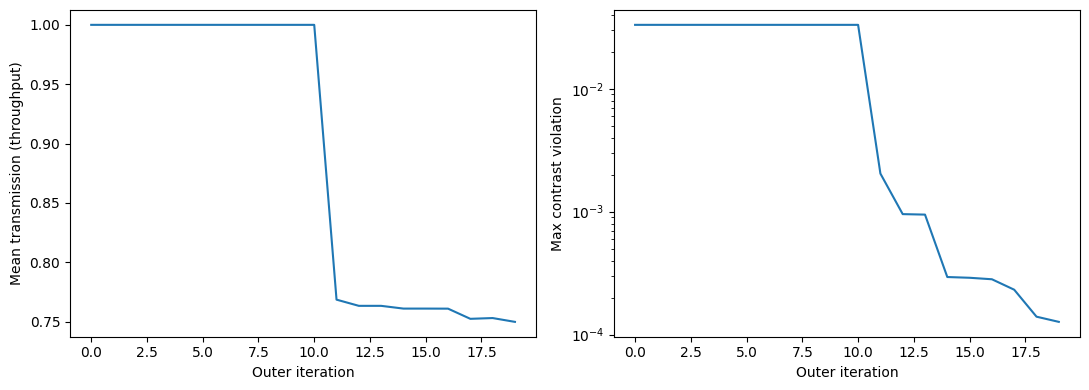

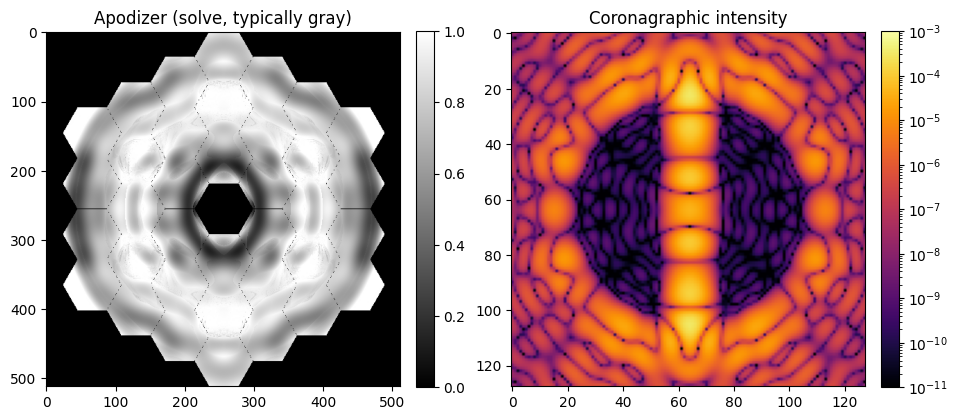

In [5]:
xf, history = model.solve(outer_steps=20, inner_steps=200, progress=True)

pupil.update(xf)
field = coro.forward(wvl, include_fpm=True)
intensity = asnumpy(np.abs(field) ** 2) / contrast_norm

throughput = [h["throughput"] / model.n_params for h in history]
violation = [h["max_violation"] for h in history]

# Convergence diagnostics: violation should fall as the constraint is enforced.
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(throughput)
ax[0].set_xlabel("Outer iteration")
ax[0].set_ylabel("Mean transmission (throughput)")
ax[1].plot(violation)
ax[1].set_xlabel("Outer iteration")
ax[1].set_ylabel("Max contrast violation")
ax[1].set_yscale("log")
plt.tight_layout()

# The design and its dark hole (typically gray at this stage).
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].set_title("Apodizer (solve, typically gray)")
im0 = ax[0].imshow(asnumpy(pupil.data), cmap="gray", vmin=0, vmax=1)
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)
ax[1].set_title("Coronagraphic intensity")
im1 = ax[1].imshow(intensity, cmap="inferno", norm=LogNorm(vmin=1e-11, vmax=1e-3))
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
plt.show()

## Graduated optimization for a *binary* apodizer

The `solve()` result enforces the constraint but is **gray**, and it is worth understanding why. With `constraint_kind="field"` the constraints are *linear*, so the feasible set is a polytope whose **vertices are binary** {0, 1} — and maximizing a linear throughput objective should land on a vertex. But the augmented Lagrangian does *not* minimize that pure linear program; its penalty term is a **quadratic**, whose minimizer is *smooth*. A large penalty `rho` rounds the binary vertex off into a gray interior point. Crucially, **running the inner solver longer does not help**: once it has converged, that gray point *is* the minimizer of the smooth objective — to move it you must change the objective, not solve it harder.

The recipe below drives a three-part schedule by hand with `model.step(...)` (which runs one outer iteration and returns `(x, info)`):

1. **Explore** — let `rho` grow (`penalty_growth=2`) to dig the dark hole and let the multipliers `lambda` converge to enforce feasibility. We also tighten the contrast target by decades (a *homotopy*) and cool the relaxation blur.
2. **Anneal `rho` down** — stop growing `rho` and anneal it toward ~0, holding the converged `lambda`, with `ftol=gtol=None` (run each inner solve to convergence) and the blur off, so the smoothing quadratic vanishes and the problem approaches the pure linear Lagrangian.
3. **Binarize (tent penalty)** — ramp up a concave binarization penalty that *actively pushes mid-gray pixels to a bound*. Use `binarize_kind="tent"`: its force is **constant toward the nearest bound everywhere, including at mid-gray**. (The default `"quadratic"` double-well has force `~(l + u - 2x)`, which *vanishes* exactly at mid-gray, so it cannot move a stuck 0.5 pixel.) Turn it on only *after* feasibility — the AL multipliers then keep the contrast satisfied while the tent force crushes the grayness.

> **This schedule is the hard part of APLC design** and the knobs interact. Ramp `binarize_weight` up *gradually and only after feasibility*: too much, too early fights the dark hole and wrecks contrast. There is a genuine **binarity ↔ contrast trade-off** — forcing gray pixels to a bound spends some contrast/throughput — so watch the printed violation as `beta` climbs. A thin gray rim at segment edges is expected (partial-pixel sampling), and is finished off with a hard threshold in the last cell. Reaching deep contrast at `1e-10` typically needs a larger iteration budget than this short demo.

In [15]:
from tqdm import tqdm

# Rebuild the model, starting fully open again, with strong throughput pressure
# and the tent binarization penalty available (off until the converge phase).
pupil.update(x0)
model = AugmentedLagrangian(
    coro=coro,
    optimizer=PrysmLBFGSB,
    dark_hole=dark_hole,
    wvl=[wvl],
    contrast=target_contrast,
    x0=x0,
    lower_bounds=np.zeros_like(x0),
    upper_bounds=np.ones_like(x0),
    constraint_kind="field",
    normalize_throughput=True,
    throughput_weight=30.0,  # strong throughput pressure; ~1 leaves the apodizer gray
    penalty=1.0,
    penalty_growth=1.0,      # we drive rho by hand below, not via auto-growth
    optimizer_kwargs={"maxls": 50},
    relaxation_sigma=4.0,    # initial blur; cooled during the explore phase
    binarize_kind="tent",    # constant force toward nearest bound, even at mid-gray
    binarize_weight=0.0,     # OFF during exploration; ramped up in the converge phase
)

n_explore = 60
n_converge = 55
sigma0, sigma_min = 4.0, 0.5      # relaxation kernel std (px), cooled geometrically
c_start = 1e-10                    # easy target to start the contrast homotopy
rho_floor = 1e-2                 # anneal rho down to here in the converge phase
beta_max = 100.0                  # final tent binarization weight (tune this)

history = []

# --- Phase 1: EXPLORE -- grow rho, dig the dark hole, converge the multipliers.
model.penalty_growth = 2.0  # let model.step() ramp rho up to drive feasibility
for i in tqdm(range(n_explore), desc="explore"):
    frac = i / max(n_explore - 1, 1)
    model.contrast[:] = c_start * (target_contrast / c_start) ** frac  # homotopy
    model.relaxation_sigma = sigma0 * (sigma_min / sigma0) ** frac     # cool blur
    model.ftol, model.gtol = 1e-4, 1e-6                                # early-exit ok
    _, info = model.step(inner_steps=300, apply_relaxation=(i < n_explore - 1))
    history.append(info)

# --- Phase 2: CONVERGE + BINARIZE -- anneal rho DOWN and ramp the tent penalty UP.
model.penalty_growth = 1.0  # stop the auto-multiply inside model.step()
rho_explore = model.penalty
for j in tqdm(range(n_converge), desc="converge"):
    b = (j + 1) / n_converge
    model.penalty = rho_explore * (rho_floor / rho_explore) ** b  # anneal rho down
    model.binarize_weight = beta_max * b   # ramp tent binarization up gradually
    model.relaxation_sigma = None          # no blur (it re-grays the apodizer)
    model.ftol, model.gtol = None, None    # run each inner solve to convergence
    _, info = model.step(inner_steps=600, apply_relaxation=False)
    history.append(info)

xf = model.x
pupil.update(xf)

converge: 100%|██████████| 55/55 [00:02<00:00, 23.98it/s]


near-binary fraction: 13.5%
mean transmission (throughput): 0.674


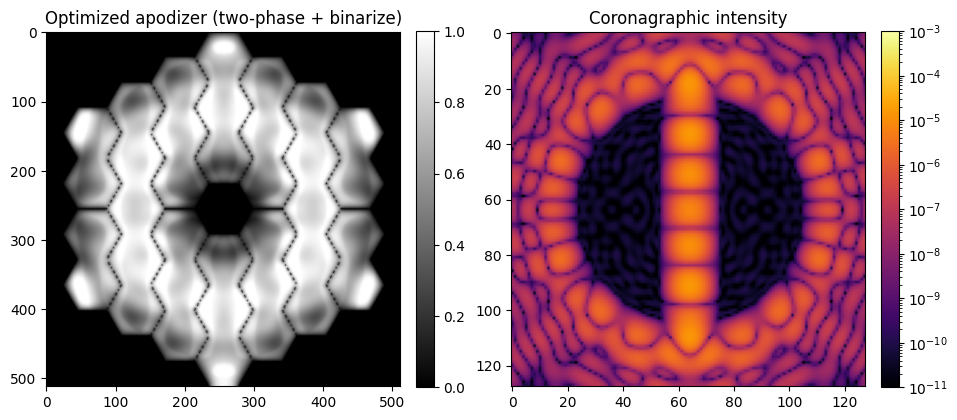

In [16]:
field = coro.forward(wvl, include_fpm=True)
intensity = asnumpy(np.abs(field) ** 2) / contrast_norm

# How binary is the apodizer? Fraction of active pixels within 5% of a bound.
x_host = asnumpy(xf)
near_binary = float(np.mean((x_host < 0.05) | (x_host > 0.95)))
print(f"near-binary fraction: {near_binary:.1%}")
print(f"mean transmission (throughput): {float(np.mean(x_host)):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].set_title("Optimized apodizer (two-phase + binarize)")
im0 = ax[0].imshow(asnumpy(pupil.data), cmap="gray", vmin=0, vmax=1)
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)
ax[1].set_title("Coronagraphic intensity")
im1 = ax[1].imshow(intensity, cmap="inferno", norm=LogNorm(vmin=1e-11, vmax=1e-3))
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
plt.show()

## Finalize: threshold and re-check contrast

The schedule above leaves at most a thin gray rim. Projecting it to a hard binary mask (`x > 0.5 -> 1`) gives the manufacturable apodizer, but thresholding *spends* some contrast — so always re-propagate the binary design and verify the dark-hole contrast against the target.

target contrast:   1.0e-10
continuous design: mean 3.73e-11  max 1.07e-10
binary design:     mean 9.26e-05  max 7.54e-04


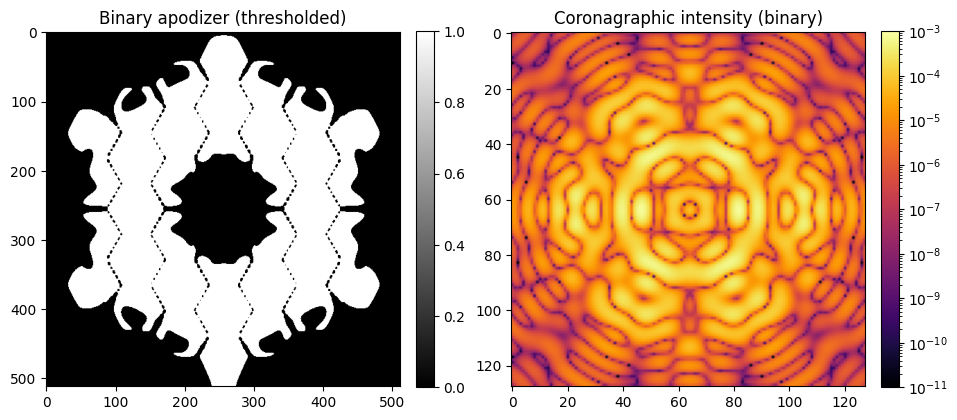

In [17]:
# Project residual gray pixels to a hard binary apodizer.
x_binary = np.where(xf > 0.5, 1.0, 0.0)

dh_host = asnumpy(dark_hole).astype(bool)

# Continuous (pre-threshold) dark-hole contrast.
pupil.update(xf)
I_cont = asnumpy(np.abs(coro.forward(wvl, include_fpm=True)) ** 2) / contrast_norm
# Binary (post-threshold) dark-hole contrast.
pupil.update(x_binary)
I_bin = asnumpy(np.abs(coro.forward(wvl, include_fpm=True)) ** 2) / contrast_norm

print(f"target contrast:   {target_contrast:.1e}")
print(f"continuous design: mean {I_cont[dh_host].mean():.2e}  max {I_cont[dh_host].max():.2e}")
print(f"binary design:     mean {I_bin[dh_host].mean():.2e}  max {I_bin[dh_host].max():.2e}")

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].set_title("Binary apodizer (thresholded)")
im0 = ax[0].imshow(asnumpy(pupil.data), cmap="gray", vmin=0, vmax=1)
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)
ax[1].set_title("Coronagraphic intensity (binary)")
im1 = ax[1].imshow(I_bin, cmap="inferno", norm=LogNorm(vmin=1e-11, vmax=1e-3))
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
plt.show()

## Recap

- `AugmentedLagrangian` poses APLC design as **maximize throughput subject to a hard contrast constraint**, so you state the contrast you want (`1e-10`) instead of grid-searching a penalty weight, and the multipliers update automatically.
- The **inner** solver is `PrysmLBFGSB` — the right choice for this smooth, box-constrained, analytic-gradient sub-problem.
- A bare `solve()` enforces the constraint but is **gray**: the *quadratic* AL penalty has a smooth minimizer, so solving harder (more inner iterations) cannot binarize it — you must change the objective.
- A binary apodizer comes from a three-part schedule: **explore** (grow `rho`, converge multipliers, contrast homotopy), **anneal `rho` down** (approach the pure linear Lagrangian), and **ramp the `"tent"` binarization penalty up** (constant force that pushes stuck mid-gray pixels to a bound). A final hard **threshold + contrast re-check** finishes the residual gray rim.
- Expect a **binarity ↔ contrast trade-off**; the schedule knobs need per-problem tuning.

For broadband designs, pass a list of wavelengths to `wvl`; the dark-hole contrast is then constrained at every wavelength simultaneously.